In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

import joblib
import os

In [ ]:
df = pd.read_excel(r"D:\Student_Dropout_Prediction_Project\student_dataset.xlsx")

df.head()

,stud_id,age,gender,location,12th_percentage,current_sem_cgpa,overall_cgpa,arrears_count,prev_sem_result,course_type,attendance_percentage,class_participation,family_income,scholarship_status,stress_level,motivation_level,interest_in_course,disciplinary_action,risk_level
0,S0001,18.0,Male,Rural,59.65,6.45,6.21,1,Fail,Science,65.05,Low,Medium,Yes,High,Low,Low,No,At Risk
1,S0002,20.0,Female,Rural,63.88,5.00,5.36,3,Fail,Engineering,63.20,Low,Low,Yes,High,Low,Low,Yes,At Risk
2,S0003,22.0,Male,Rural,62.64,5.63,6.16,3,Fail,Science,73.80,Medium,Medium,Yes,High,High,High,No,At Risk
3,S0004,19.0,Female,Urban,62.15,6.56,7.01,2,Fail,Science,63.51,Low,Medium,Yes,High,Low,Low,Yes,At Risk
4,S0005,19.0,Female,Urban,56.60,6.18,7.01,1,Fail,Arts,63.23,Low,Medium,Yes,High,Low,Low,No,At Risk


In [ ]:
# remove student id
df = df.drop(columns=["stud_id"])

# convert arrears to integer
df["arrears_count"] = df["arrears_count"].astype(int)

# remove duplicates
df = df.drop_duplicates()

# reset index
df = df.reset_index(drop=True)

print("Dataset Shape:", df.shape)

Dataset Shape: (2382, 18)


In [ ]:
print(df["risk_level"].value_counts())

risk_level
At Risk            794
Needs Attention    794
Stable             794
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=["risk_level"])

y = df["risk_level"]

In [ ]:
X_encoded = X.copy()

le_dict = {}

for col in X_encoded.columns:

    if X_encoded[col].dtype == "object":

        le = LabelEncoder()

        X_encoded[col] = le.fit_transform(X_encoded[col])

        le_dict[col] = le

In [ ]:
le_target = LabelEncoder()

y_encoded = le_target.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

In [ ]:
param_grid = {

    "n_estimators": [400, 500, 600, 700],

    "max_depth": [10, 12, 15, 18],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4],

    "max_features": ["sqrt", "log2"]
}

In [ ]:
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

In [ ]:
search = RandomizedSearchCV(
    rf,
    param_grid,
    n_iter=20,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42
)

In [ ]:
search.fit(X_train, y_train)

model = search.best_estimator_

print("Best Parameters:")

print(search.best_params_)

Best Parameters:
{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 18}


In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9853249475890985


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=le_target.classes_
    )
)

                 precision    recall  f1-score   support

        At Risk       0.99      0.99      0.99       159
Needs Attention       0.97      0.98      0.98       159
         Stable       0.99      0.98      0.99       159

       accuracy                           0.99       477
      macro avg       0.99      0.99      0.99       477
   weighted avg       0.99      0.99      0.99       477



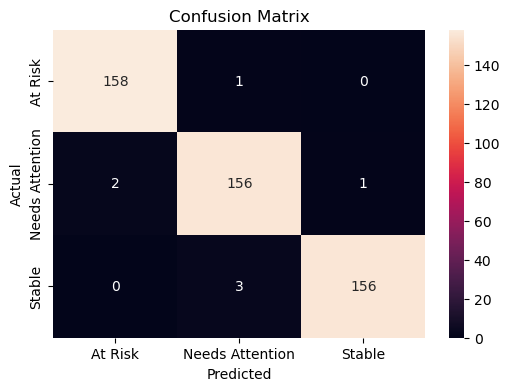

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le_target.classes_,
    yticklabels=le_target.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

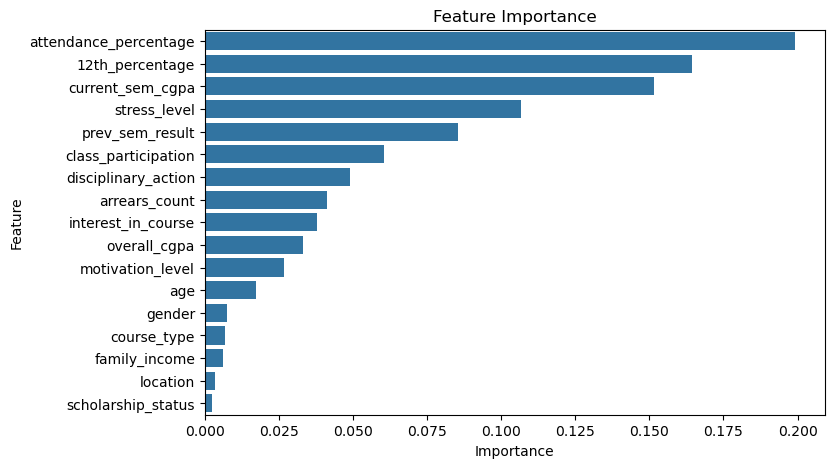

In [ ]:
importance = model.feature_importances_

features = X_encoded.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Feature Importance")

plt.show()

In [ ]:
save_path = r"D:\Student_Dropout_Prediction_Project"

joblib.dump(
    model,
    os.path.join(save_path, "risk_prediction_model.pkl")
)

joblib.dump(
    le_dict,
    os.path.join(save_path, "encoders.pkl")
)

joblib.dump(
    le_target,
    os.path.join(save_path, "target_encoder.pkl")
)

print("Model Saved Successfully!")

Model Saved Successfully!
